In [1]:
import numpy as np
import pandas as pd

In [2]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Flatten

In [27]:
(X_train,y_train),(X_test,y_test) = keras.datasets.mnist.load_data()

In [28]:
X_train.shape

(60000, 28, 28)

In [29]:
X_test.shape

(10000, 28, 28)

In [30]:
y_train

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

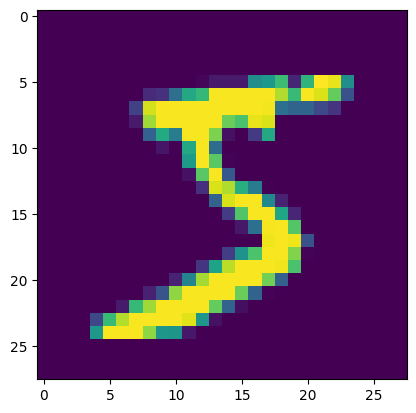

In [31]:
import matplotlib.pyplot as plt
plt.imshow(X_train[0])

In [32]:
# convert pixel range from (0-255) -> (0-1)
X_train = X_train/255
X_test = X_test/255

In [49]:
model = Sequential()

model.add(Flatten(input_shape=(28,28)))
model.add(Dense(128,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(10,activation='softmax'))

C:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [50]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,938 (409.91 KB)

 Trainable params: 104,938 (409.91 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [52]:
history = model.fit(X_train,y_train,epochs=30,validation_split=0.2)

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9160 - loss: 0.2836 - val_accuracy: 0.9580 - val_loss: 0.1435
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9637 - loss: 0.1232 - val_accuracy: 0.9673 - val_loss: 0.1054
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9741 - loss: 0.0840 - val_accuracy: 0.9712 - val_loss: 0.0914
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9805 - loss: 0.0626 - val_accuracy: 0.9702 - val_loss: 0.0976
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9847 - loss: 0.0481 - val_accuracy: 0.9715 - val_loss: 0.1038
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9868 - loss: 0.0406 - val_accuracy: 0.9731 - val_loss: 0.0956
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9895 - loss: 0.0319 - val_accuracy: 0.9736 - val_loss: 0.1001
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9903 - loss: 0.0284 - 

In [53]:
y_prob = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [54]:
y_prob

array([[2.4143976e-13, 7.0562571e-15, 2.5006727e-14, ..., 1.0000000e+00,
        2.1765229e-16, 3.1497902e-10],
       [1.0705944e-16, 2.3825898e-13, 1.0000000e+00, ..., 1.5073001e-31,
        1.0935565e-12, 4.9163713e-24],
       [3.5227186e-12, 9.9999988e-01, 5.5103619e-08, ..., 6.3070384e-09,
        1.3217126e-08, 3.1430004e-11],
       ...,
       [2.0614584e-26, 7.1497920e-22, 3.6762490e-27, ..., 2.1174008e-18,
        1.0427535e-18, 4.0160980e-14],
       [1.4333271e-27, 3.9801228e-24, 0.0000000e+00, ..., 1.2046385e-24,
        9.9982321e-11, 2.3542496e-27],
       [2.3727830e-22, 1.6157028e-24, 2.0070829e-22, ..., 7.2259030e-31,
        1.5848796e-19, 2.3866439e-23]], shape=(10000, 10), dtype=float32)

In [55]:
y_pred = y_prob.argmax(axis=1)

In [56]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9754

In [59]:
history.history

{'accuracy': [0.9160208106040955,
  0.9636874794960022,
  0.9741458296775818,
  0.9805208444595337,
  0.984666645526886,
  0.9867916703224182,
  0.9894583225250244,
  0.9902708530426025,
  0.9927291870117188,
  0.9931250214576721,
  0.9939374923706055,
  0.9948541522026062,
  0.9947291612625122,
  0.9950416684150696,
  0.9959583282470703,
  0.9965624809265137,
  0.9962083101272583,
  0.9962708353996277,
  0.9969791769981384,
  0.9972708225250244,
  0.9972708225250244,
  0.9963958263397217,
  0.9978333115577698,
  0.9966041445732117,
  0.9973541498184204,
  0.9981041550636292,
  0.996874988079071,
  0.9977083206176758,
  0.9973958134651184,
  0.9977291822433472],
 'loss': [0.2836378812789917,
  0.12315186858177185,
  0.08396147936582565,
  0.06259501725435257,
  0.04806569591164589,
  0.04063127189874649,
  0.03190956637263298,
  0.02843352034687996,
  0.022408846765756607,
  0.020291969180107117,
  0.018403135240077972,
  0.015330083668231964,
  0.016120968386530876,
  0.01431901659816

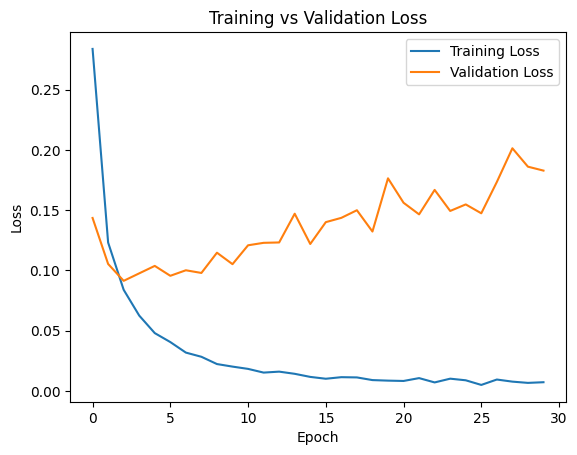

In [67]:
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

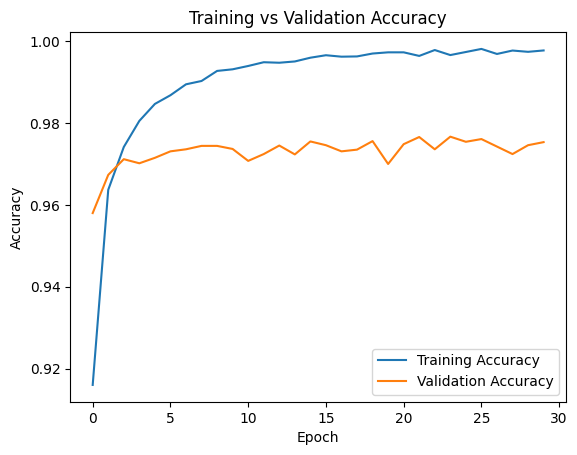

In [68]:
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

np.uint8(9)

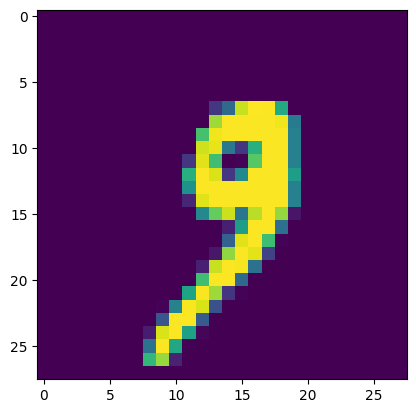

In [77]:
plt.imshow(X_test[1000])
y_test[1000]

In [78]:
model.predict(X_test[1000].reshape(1,28,28)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


array([9])